In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plt.rcParams.update({'font.size': 14})

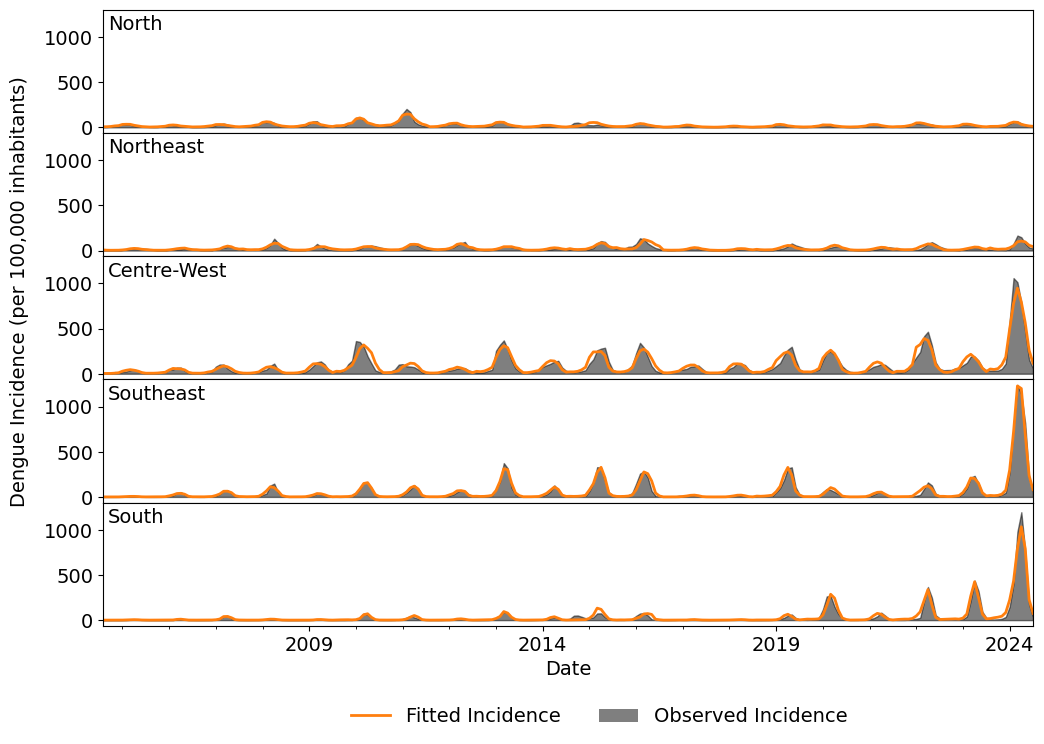

In [8]:
df_standard = pd.read_csv('data/dengue_regional_aggregation.csv', parse_dates=['date_first_symptoms'])

fig, axarr = plt.subplots(5, 1, figsize=(12, 8), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0, hspace=0)

for i, region in enumerate(['North', 'Northeast', 'Middle-West', 'Southeast', 'South']):
    ax = axarr[i]
    region_df = df_standard[df_standard['region'] == region].set_index('date_first_symptoms')
    region_df['pred_regional_incidence'].plot(ax=ax, legend=False, color='C1', lw=2)
    ax.fill_between(
        region_df.index, 
        0, 
        region_df['actual_regional_incidence'], 
        color='k', alpha=0.5
    )
    
    if region == 'Middle-West':
        ax.text(0.005, 0.88, 'Centre-West', transform=ax.transAxes, fontsize=14, va='center', ha='left')
    else:
        ax.text(0.005, 0.88, region, transform=ax.transAxes, fontsize=14, va='center', ha='left')

ax.set_xlabel('Date')
ax.text(-0.1, 1, 'Dengue Incidence (per 100,000 inhabitants)', rotation=90, transform=ax.transAxes)


# ---- LEGEND ----
legend_elements = [
    Line2D([0], [0], color='C1', lw=2, label='Fitted Incidence'),
    Patch(facecolor='k', alpha=0.5, label='Observed Incidence'),
]
fig.legend(handles=legend_elements, frameon=False, ncol=2, bbox_to_anchor=(0.76, 0.03))

plt.savefig('img/figure2_timeseries.pdf', dpi=300, bbox_inches='tight')

/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_2560/3924453816.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_2560/3924453816.py:116: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prsq_normed = df_prsq.grou

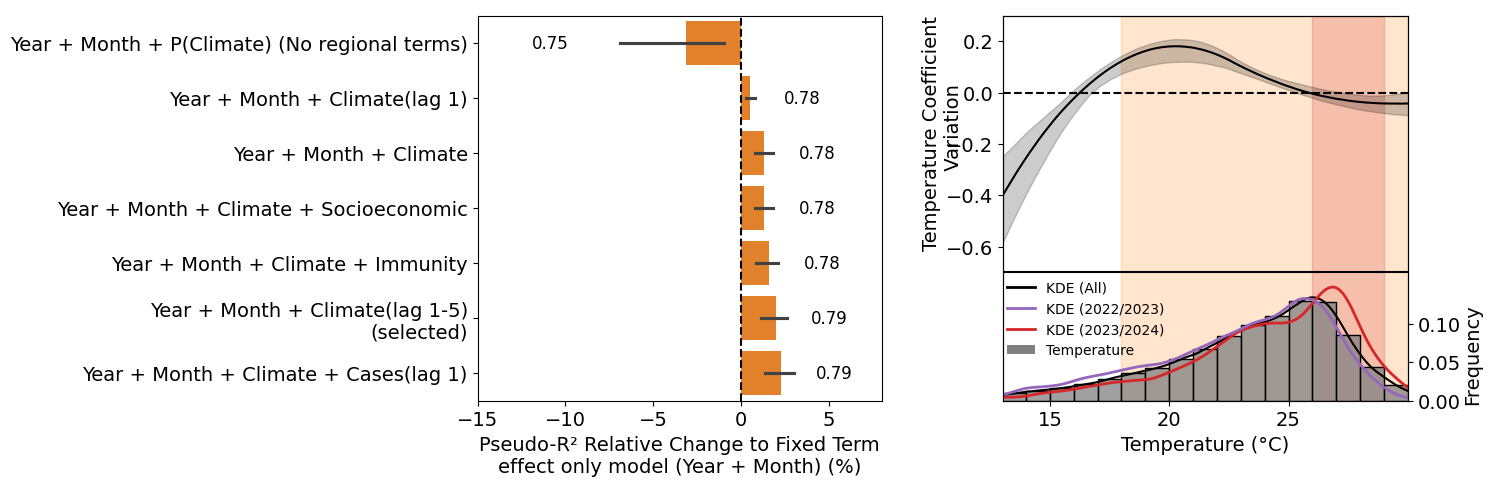

In [10]:
coefficients = pd.read_csv('data/lag_45_coef_state_blockboot1000.csv')
df = pd.read_csv('data/model_input_brazil_immunity_city.csv', parse_dates=['date_first_symptoms'])
df['year'] = df['date_first_symptoms'].apply(lambda x: x.year + 1 if x.month >= 8 else x.year)
bsplines = pd.read_csv('data/temperature_bsplines.csv')

temp_coef = []
for i, coefs in coefficients.iterrows():

    temp_variation = pd.DataFrame({
        'coef': (
            bsplines['bs_1'] * coefs['temp_bs_lag11'] + \
            bsplines['bs_2'] * coefs['temp_bs_lag12'] + \
            bsplines['bs_3'] * coefs['temp_bs_lag13'] + \
            bsplines['bs_4'] * coefs['temp_bs_lag14'] + \
            bsplines['bs_1'] * coefs['temp_bs_lag21'] + \
            bsplines['bs_2'] * coefs['temp_bs_lag22'] + \
            bsplines['bs_3'] * coefs['temp_bs_lag23'] + \
            bsplines['bs_4'] * coefs['temp_bs_lag24'] + \
            bsplines['bs_1'] * coefs['temp_bs_lag31'] + \
            bsplines['bs_2'] * coefs['temp_bs_lag32'] + \
            bsplines['bs_3'] * coefs['temp_bs_lag33'] + \
            bsplines['bs_4'] * coefs['temp_bs_lag34'] + \
            bsplines['bs_1'] * coefs['temp_bs_lag41'] + \
            bsplines['bs_2'] * coefs['temp_bs_lag42'] + \
            bsplines['bs_3'] * coefs['temp_bs_lag43'] + \
            bsplines['bs_4'] * coefs['temp_bs_lag44'] + \
            bsplines['bs_1'] * coefs['temp_bs_lag51'] + \
            bsplines['bs_2'] * coefs['temp_bs_lag52'] + \
            bsplines['bs_3'] * coefs['temp_bs_lag53'] + \
            bsplines['bs_4'] * coefs['temp_bs_lag54'] 
        ),
        'temp': bsplines['temperature']
    })

    temp_variation['model'] = i
    temp_coef.append(temp_variation)

temp_coef = pd.concat(temp_coef)
temp_coef_variation = temp_coef.groupby('model').apply(lambda x: x.set_index('temp')['coef'].diff()).reset_index().transpose()
temp_coef_variation = temp_coef_variation.drop('model')

fig, [ax2, ax1] = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'wspace': 0.3})

quantiles = temp_coef_variation.quantile([0.025, 0.5, 0.975], axis=1).transpose().reset_index()
quantiles['temp'] = quantiles['temp'].astype(float)
axt = ax1.twinx()

ax1.axvspan(18, 34, color='C1', alpha=0.2)
ax1.axvspan(26, 29, color='C3', alpha=0.2)

#df['mean_2m_air_temp_degree1'].plot.hist(ax=axt, density=True, color='lightgrey', bins=20,)
sns.histplot(df['mean_2m_air_temp_degree1'], bins=np.arange(10,31,1), stat='density', color='gray', ax=axt)

quantiles.plot(x='temp', y=0.5, ax=ax1, color='k', legend=False)
ax1.fill_between(
    quantiles['temp'],
    quantiles[0.025],
    quantiles[0.975],
    color='k', alpha=0.2
)

sns.kdeplot(df, x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='k')
sns.kdeplot(df[df['year'] == 2024], x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='C3', linewidth=2)
sns.kdeplot(df[df['year'] == 2023], x='mean_2m_air_temp_degree1', ax=axt, legend=False, color='C4', linewidth=2)

legend_elements = []
legend_elements.append(Line2D([0], [0], color='k', lw=2, label='KDE (All)'))
legend_elements.append(Line2D([0], [0], color='C4', lw=2, label='KDE (2022/2023)'))
legend_elements.append(Line2D([0], [0], color='C3', lw=2, label='KDE (2023/2024)'))
legend_elements.append(Patch(facecolor='grey', label='Temperature'))

# Place legend on the figure level or first axis
axt.legend(handles=legend_elements, frameon=False, bbox_to_anchor=(0.43, 0.08), fontsize=10)


ax1.axhline(0, color='k', ls='--')
ax1.set_ylim([-1.2, 0.3])
ax1.axhline(-0.7, color='k', ls='-')
ax1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2])
ax1.set_xlim(df['mean_2m_air_temp_degree1'].quantile(0.01), df['mean_2m_air_temp_degree1'].quantile(0.99))
axt.set_ylim([0, 0.5])
axt.set_yticks([0, 0.05, 0.1])
ax1.text(10.5, -0.6, 'Temperature Coefficient \n Variation', color='k', rotation=90, ha='center')
#ax1.set_ylabel('Temperature Coefficient Variation')
ax1.set_xlabel('Temperature (°C)')
axt.set_ylabel('')
axt.text(32.3, 0, 'Frequency', color='k', rotation=90)

legend_elements = []
legend_elements.append(Line2D([0], [0], color='k', lw=2, label='Coef.'))


##########
model_names = { 
    'childs': 'Year + Month + P(Climate) (No regional terms)', 
    'lag1': 'Year + Month + Climate(lag 1)', 
    'lag_45': 'Year + Month + Climate(lag 1-5)\n(selected)', 
    'standard': 'Year + Month + Climate', 
    'with_immunity': 'Year + Month + Climate + Immunity', 
    'base': 'Year + Month',
    'socioeconomic': 'Year + Month + Climate + Socioeconomic',
    'lag1_cases': 'Year + Month + Climate + Cases(lag 1)'
}


##########
df = pd.concat([
    pd.read_csv(f'../peru_dengue/{model}_rsquared_aic_state_blockboot_presampled1000.csv') for model in model_names.keys()
])

df['model_name'] = df['model_name'].map(model_names)
df = df.reset_index().drop('index', axis=1)

df_prsq = df.copy()

prsq_normed = df_prsq.groupby('bootstrap_iteration').apply(lambda x: 100 * (x['pseudo_r_squared'] / x.loc[x['model_name'] == 'Year + Month', 'pseudo_r_squared'].values[0] - 1)).reset_index().sort_values('level_1')
df_prsq = df_prsq.join(prsq_normed.set_index('level_1').rename(columns={'pseudo_r_squared': 'r_squared_normed'})[['r_squared_normed']])
df_prsq = df_prsq[df_prsq['model_name'] != 'Year + Month']

order = [
    'Year + Month + P(Climate) (No regional terms)', 
    'Year + Month + Climate(lag 1)', 'Year + Month + Climate', 
    'Year + Month + Climate + Socioeconomic', 
    'Year + Month + Climate + Immunity', 
    'Year + Month + Climate(lag 1-5)\n(selected)',
    'Year + Month + Climate + Cases(lag 1)',
]

sns.barplot(
    y='model_name', x='r_squared_normed', data=df_prsq, errorbar=('pi', 95), orient='h', ax=ax2, color='C1', 
    order=order
)


ax2.axvline(0, color='k', ls='--')
ax2.set_ylabel('')
ax2.set_xlim([-15, 8])

ax2.set_xlabel('Pseudo-R² Relative Change to Fixed Term\neffect only model (Year + Month) (%)')

for i, model in enumerate(order):

    prsq = df_prsq[df_prsq['model_name'] == model]['pseudo_r_squared'].median()
    prsq_normed = df_prsq[df_prsq['model_name'] == model]['r_squared_normed'].median()

    if prsq is not np.nan:        
        if prsq_normed > 0:
            ax2.text(prsq_normed + 3, i, f'{prsq:.2f}', color='k', fontsize=12, va='center', ha='center')
        else:
            ax2.text(prsq_normed - 8, i, f'{prsq:.2f}', color='k', fontsize=12, va='center', ha='center')

plt.savefig('img/figure2_temp_coef.pdf', dpi=300, bbox_inches='tight')